# PEFT Fine-Tuning Comparison v2 —
## LoRA vs VeRA vs DoRA vs AdaLoRA vs IA3 vs TinyLoRA on CIFAR-10

1. Random seed = 42 everywhere, for reproducibility.
2. Full CIFAR-10 training set split 80/20 into sub-train / validation (no more 5,000-sample subset).
3. 10 epochs for all experiments. LR grid = {0.001, 0.0005} compared for every method **except VeRA**, which uses a fixed LR = 0.01 (see the VeRA fix from last iteration — its scaling-vector parameterization needs a much larger LR to move at all, so the 0.001/0.0005 grid isn't meaningful for it).
4. `target_modules = q_proj|v_proj` (attention only).
5. Model selection is done on the **validation** set; the reported number for each run is **test accuracy on the untouched full 10,000-image test set**, evaluated exactly once per run using the best-validation checkpoint.
6. Six methods: LoRA, VeRA, DoRA, AdaLoRA, IA3, TinyLoRA.
7. All test accuracies (plus val accuracy, F1, timing) are saved to JSON/Markdown for the report.

**Runtime note:** this is 11 total training runs (LoRA×2 LR, VeRA×1, DoRA×2, AdaLoRA×2, IA3×2, TinyLoRA×2), each 10 epochs over the *full* 40,000-image sub-training set. That's roughly 8x more data per epoch than the previous 5,000-sample version. Mixed-precision (AMP) is enabled below to help, but budget real GPU time for this — on a T4 this can take many hours; on an A100 it will be substantially faster. Results are saved incrementally after each run so a crash or timeout doesn't lose completed runs.

## 1. Setup and Installation

In [2]:
# Mount Google Drive (optional, for saving results)
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import subprocess
import sys

packages = [
    'peft>=0.19.1',   # TinyLoraConfig, AdaLoraConfig, IA3Config, VeraConfig all live here
    'transformers',
    'torch',
    'torchvision',
    'accelerate',
    'datasets',
    'numpy',
    'matplotlib',
    'tqdm',
    'scikit-learn',
]

print("Installing required packages...")
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade'] + packages)
print("Installation complete!")


In [3]:
# Verify GPU availability
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


PyTorch version: 2.11.0+cu128
GPU available: True
GPU name: NVIDIA L4
GPU memory: 23.66 GB


## 2. Imports, Global Config, and Reproducibility

In [4]:
import os
import json
import random
import copy
import shutil
from pathlib import Path
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.transforms import Resize
from transformers import AutoModel
from peft import (
    get_peft_model,
    LoraConfig,
    VeraConfig,
    AdaLoraConfig,
    IA3Config,
    TinyLoraConfig,
    PeftModel,
)
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

# ---- Global config ----
SEED = 42
EPOCHS = 10
LR_GRID = [0.001, 0.0005]          # compared for every method except VeRA
VERA_LEARNING_RATE = 0.01          # VeRA needs a much larger LR (see prior fix); not part of the grid comparison
BATCH_SIZE = 64
TARGET_MODULES = r".*(q_proj|v_proj)$"
MODEL_NAME = 'google/vit-base-patch16-224-in21k'
VAL_FRACTION = 0.20                # 80/20 split of the TRAINING set only

def set_seed(seed=SEED):
    """Reset every RNG so each run starts from an identical, reproducible state."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"Seed: {SEED} | Epochs: {EPOCHS} | LR grid: {LR_GRID} | VeRA LR: {VERA_LEARNING_RATE}")


Using device: cuda
Seed: 42 | Epochs: 10 | LR grid: [0.001, 0.0005] | VeRA LR: 0.01


## 3. Data Preparation

Per the professor's instructions:
- **Do not subsample.** Load the full CIFAR-10 training set (50,000 images) and the full test set (10,000 images).
- Split the **training set only** into sub-train (80%) and validation (20%), stratified by class so each split has balanced classes, with `random_state=42` for reproducibility.
- The **test set is never split or touched** until final evaluation of the best checkpoint.
- Validation images use the *test-time* transform (no random flip/crop) since validation should reflect eval-time conditions, not augmented training views — augmenting the val set would make "best validation accuracy" a noisier, biased signal for model selection.

In [5]:
# Define data transformations
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2470, 0.2435, 0.2616]
    )
])

transform_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2470, 0.2435, 0.2616]
    )
])

print("Loading full CIFAR-10 dataset (no subsetting)...")

# Two dataset objects over the SAME underlying files: one with train-time augmentation,
# one with eval-time-only transform. We then split indices once (seeded, stratified) and
# apply the augmented dataset to the sub-train indices, the eval-transform dataset to the
# validation indices. This avoids ever running augmentation on the validation split.
train_dataset_aug = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
train_dataset_noaug = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_eval)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_eval)

# Stratified 80/20 split of the TRAINING set only, seeded for reproducibility
all_indices = list(range(len(train_dataset_aug)))
all_labels = train_dataset_aug.targets
train_idx, val_idx = train_test_split(
    all_indices,
    test_size=VAL_FRACTION,
    random_state=SEED,
    shuffle=True,
    stratify=all_labels,
)

sub_train_dataset = Subset(train_dataset_aug, train_idx)     # 80%, augmented
val_dataset = Subset(train_dataset_noaug, val_idx)           # 20%, eval transform only
# test_dataset is used whole, untouched

print(f"Sub-train size : {len(sub_train_dataset)} (80% of 50,000 train images)")
print(f"Validation size: {len(val_dataset)} (20% of 50,000 train images)")
print(f"Test size      : {len(test_dataset)} (full test set, untouched)")
print(f"Number of classes: 10")


Loading full CIFAR-10 dataset (no subsetting)...


100%|██████████| 170M/170M [1:37:47<00:00, 29.1kB/s]


Sub-train size : 40000 (80% of 50,000 train images)
Validation size: 10000 (20% of 50,000 train images)
Test size      : 10000 (full test set, untouched)
Number of classes: 10


In [6]:
# Create data loaders
g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(
    sub_train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True, generator=g
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")
print(f"Test batches : {len(test_loader)}")


Train batches: 625
Val batches  : 157
Test batches : 157


## 4. Model Setup with Classification Head

In [7]:
class CIFAR10ClassificationModel(nn.Module):
    """Wrapper for ViT with classification head for CIFAR-10"""
    def __init__(self, model_name=MODEL_NAME, num_classes=10):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name, trust_remote_code=True)
        self.hidden_size = self.backbone.config.hidden_size
        self.classifier = nn.Linear(self.hidden_size, num_classes)

    def forward(self, pixel_values):
        outputs = self.backbone(pixel_values)
        cls_output = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(cls_output)
        return logits

def build_base_model():
    """Fresh, identically-initialized base model for each run (seed is reset by caller)."""
    model = CIFAR10ClassificationModel(MODEL_NAME)
    return model.to(device)

print("Model class defined successfully!")


Model class defined successfully!


## 5. Training and Evaluation Functions

In [8]:
def resize_images(images, target_size=224):
    """Resize CIFAR-10 images (32x32) to target size for ViT"""
    resizer = Resize((target_size, target_size))
    return resizer(images)

def train_epoch(model, loader, optimizer, criterion, device, epoch, total_epochs, scaler=None):
    """Train for one epoch. Uses AMP mixed precision when a GradScaler is provided."""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{total_epochs}", leave=False)
    for images, labels in pbar:
        images = resize_images(images, target_size=224).to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        if scaler is not None:
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                logits = model(images)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        _, predicted = logits.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix({'loss': total_loss / max(1, total // labels.size(0)), 'acc': 100 * correct / total})

    return total_loss / len(loader), 100 * correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device, desc="Evaluating"):
    """Evaluate model on a given loader (used for both validation and test)."""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc=desc, leave=False)
    for images, labels in pbar:
        images = resize_images(images, target_size=224).to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        total_loss += loss.item()
        _, predicted = logits.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return total_loss / len(loader), accuracy, f1

def count_parameters(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total

print("Training and evaluation functions defined!")


Training and evaluation functions defined!


## 6. Generalized Experiment Runner

One function drives every method/LR combination identically:
- resets the seed,
- trains for `EPOCHS` epochs, tracking **train** and **validation** metrics each epoch,
- keeps the model weights from the epoch with the **best validation accuracy** (in memory, `copy.deepcopy`'d state dict — avoids repeated disk I/O across 11 runs),
- after training, loads those best-validation weights and evaluates **once** on the untouched test set,
- (AdaLoRA only) calls `update_and_allocate` after every optimizer step, as its dynamic rank-pruning schedule requires.

In [9]:
def run_experiment(method_name, lr, peft_model, epochs=EPOCHS, is_adalora=False, use_amp=True, seed=SEED):
    """
    Train `peft_model` (already wrapped by get_peft_model) for `epochs` epochs.
    Model selection uses validation accuracy; final reported metric is test accuracy
    from the best-validation checkpoint, computed exactly once.
    """
    set_seed(seed)  # re-seed so data order / dropout / init noise is identical across LR variants

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(peft_model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.cuda.amp.GradScaler() if (use_amp and device.type == 'cuda') else None

    total_steps = epochs * len(train_loader)
    global_step = 0

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
    best_val_acc = -1.0
    best_state = None
    start_time = datetime.now()

    for epoch in range(epochs):
        # --- train ---
        peft_model.train()
        total_loss, correct, total = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f"[{method_name} lr={lr}] Epoch {epoch+1}/{epochs}", leave=False)
        for images, labels in pbar:
            images = resize_images(images, target_size=224).to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            if scaler is not None:
                with torch.autocast(device_type='cuda', dtype=torch.float16):
                    logits = peft_model(images)
                    loss = criterion(logits, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                logits = peft_model(images)
                loss = criterion(logits, labels)
                loss.backward()
                optimizer.step()

            if is_adalora:
                # AdaLoRA's dynamic rank allocation must be updated every optimizer step
                peft_model.base_model.update_and_allocate(global_step)
            global_step += 1

            total_loss += loss.item()
            _, predicted = logits.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
            pbar.set_postfix({'loss': total_loss / max(1, total // labels.size(0)), 'acc': 100 * correct / total})

        train_loss, train_acc = total_loss / len(train_loader), 100 * correct / total

        # --- validate ---
        val_loss, val_acc, val_f1 = evaluate(peft_model, val_loader, criterion, device, desc="Validating")
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        print(f"[{method_name} lr={lr}] Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% F1: {val_f1:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(peft_model.state_dict())
            print(f"  best checkpoint updated (val acc: {best_val_acc:.2f}%)")

    training_time = (datetime.now() - start_time).total_seconds()

    # Load best-validation weights, then evaluate on the TEST set exactly once
    peft_model.load_state_dict(best_state)
    test_loss, test_acc, test_f1 = evaluate(peft_model, test_loader, criterion, device, desc="Final test eval")

    print(f"[{method_name} lr={lr}] DONE | best val acc: {best_val_acc:.2f}% | "
          f"TEST acc: {test_acc:.2f}% | test F1: {test_f1:.4f} | time: {training_time:.1f}s")

    return {
        'history': history,
        'best_val_acc': best_val_acc,
        'test_loss': test_loss,
        'test_acc': test_acc,
        'test_f1': test_f1,
        'training_time_seconds': training_time,
    }


## 7. Method Configuration Factory

Builds a fresh base model + PEFT-wrapped model for a given `(method, lr)` pair. Each call re-seeds first, so every method starts from the identical base-model initialization.

In [10]:
def build_peft_model(method_name, epochs=EPOCHS):
    """Returns (peft_model, is_adalora_flag). Always builds a fresh base model first."""
    set_seed(SEED)
    base = build_base_model()

    if method_name == 'LoRA':
        cfg = LoraConfig(r=8, lora_alpha=16, target_modules=TARGET_MODULES, lora_dropout=0.1, bias='none')
        return get_peft_model(base, cfg), False

    elif method_name == 'VeRA':
        cfg = VeraConfig(r=8, target_modules=TARGET_MODULES)
        return get_peft_model(base, cfg), False

    elif method_name == 'DoRA':
        cfg = LoraConfig(r=8, lora_alpha=16, target_modules=TARGET_MODULES, lora_dropout=0.1,
                          bias='none', use_dora=True)
        return get_peft_model(base, cfg), False

    elif method_name == 'AdaLoRA':
        total_step = epochs * len(train_loader)
        cfg = AdaLoraConfig(
            init_r=12, target_r=8,                       # start at rank 12, prune down to 8
            target_modules=TARGET_MODULES,
            lora_alpha=16, lora_dropout=0.1, bias='none',
            tinit=int(0.1 * total_step),                  # warm-up steps before pruning starts
            tfinal=int(0.7 * total_step),                 # steps at which final rank is reached
            deltaT=10,
            total_step=total_step,
        )
        return get_peft_model(base, cfg), True

    elif method_name == 'IA3':
        cfg = IA3Config(target_modules=TARGET_MODULES, feedforward_modules=[])  # attention-only, no MLP targets
        return get_peft_model(base, cfg), False

    elif method_name == 'TinyLoRA':
        cfg = TinyLoraConfig(r=2, u=64, target_modules=TARGET_MODULES, projection_seed=SEED)
        return get_peft_model(base, cfg), False

    else:
        raise ValueError(f"Unknown method: {method_name}")


## 8. Run All Experiments

Per the spec: LoRA, DoRA, AdaLoRA, IA3, TinyLoRA are each run at **both** LR = 0.001 and LR = 0.0005 for comparison. VeRA is run once at its own LR = 0.01. Results are saved to disk after every single run, so a crash partway through the sweep doesn't lose completed work — just re-run this cell and it will pick up where the results file left off.

In [11]:
RESULTS_PATH = Path('/content/drive/MyDrive/PEFT_Results/all_results_v2.json') if os.path.exists('/content/drive/MyDrive') else Path('./all_results_v2.json')
RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)

# Load any previously-completed runs (resumability across sessions)
if RESULTS_PATH.exists():
    with open(RESULTS_PATH) as f:
        all_results = json.load(f)
    print(f"Resuming: {len(all_results)} run(s) already completed: {list(all_results.keys())}")
else:
    all_results = {}

# Build the full list of (method, lr) runs per the professor's spec
run_plan = []
for method in ['LoRA', 'DoRA', 'AdaLoRA', 'IA3', 'TinyLoRA']:
    for lr in LR_GRID:
        run_plan.append((method, lr))
run_plan.append(('VeRA', VERA_LEARNING_RATE))  # VeRA: single fixed LR, not part of the grid comparison

print(f"Total runs planned: {len(run_plan)}")
for m, lr in run_plan:
    print(f"  {m:10s} lr={lr}")


Total runs planned: 11
  LoRA       lr=0.001
  LoRA       lr=0.0005
  DoRA       lr=0.001
  DoRA       lr=0.0005
  AdaLoRA    lr=0.001
  AdaLoRA    lr=0.0005
  IA3        lr=0.001
  IA3        lr=0.0005
  TinyLoRA   lr=0.001
  TinyLoRA   lr=0.0005
  VeRA       lr=0.01


In [13]:
!pip install -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 106.8 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [14]:
for method_name, lr in run_plan:
    run_key = f"{method_name}_lr{lr}"
    if run_key in all_results:
        print(f"Skipping {run_key} (already completed)")
        continue

    print("\n" + "=" * 70)
    print(f"RUN: {run_key}")
    print("=" * 70)

    try:
        peft_model, is_adalora = build_peft_model(method_name, epochs=EPOCHS)
        trainable, total = count_parameters(peft_model)
        print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.3f}%)")

        result = run_experiment(method_name, lr, peft_model, epochs=EPOCHS, is_adalora=is_adalora)
        result['method'] = method_name
        result['lr'] = lr
        result['trainable_params'] = trainable
        result['total_params'] = total
        result['status'] = 'success'

        del peft_model
        torch.cuda.empty_cache()

    except Exception as e:
        import traceback
        print(f"RUN FAILED: {run_key}\n{traceback.format_exc()}")
        result = {'method': method_name, 'lr': lr, 'status': 'failed', 'error': str(e)}

    all_results[run_key] = result
    with open(RESULTS_PATH, 'w') as f:
        json.dump(all_results, f, indent=2)
    print(f"Saved progress to {RESULTS_PATH} ({len(all_results)}/{len(run_plan)} runs done)")

print("\nAll runs complete (or already were).")


Skipping LoRA_lr0.001 (already completed)
Skipping LoRA_lr0.0005 (already completed)
Skipping DoRA_lr0.001 (already completed)
Skipping DoRA_lr0.0005 (already completed)

RUN: AdaLoRA_lr0.001


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

/tmp/ipykernel_693/2733642907.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if (use_amp and device.type == 'cuda') else None


Trainable params: 442,656 / 86,839,618 (0.510%)


[AdaLoRA lr=0.001] Epoch 1/10 | Train Loss: 0.7582 Acc: 86.85% | Val Loss: 0.3427 Acc: 97.98% F1: 0.9798
  best checkpoint updated (val acc: 97.98%)


...

[VeRA lr=0.01] Epoch 7/10 | Train Loss: 0.7148 Acc: 94.96% | Val Loss: 0.7927 Acc: 94.12% F1: 0.9411


[VeRA lr=0.01] Epoch 8/10 | Train Loss: 0.7049 Acc: 95.12% | Val Loss: 0.7853 Acc: 94.26% F1: 0.9425


[VeRA lr=0.01] Epoch 9/10 | Train Loss: 0.6954 Acc: 95.44% | Val Loss: 0.7788 Acc: 94.50% F1: 0.9450
  best checkpoint updated (val acc: 94.50%)


[VeRA lr=0.01] Epoch 10/10 | Train Loss: 0.6919 Acc: 95.60% | Val Loss: 0.7788 Acc: 94.30% F1: 0.9430


[VeRA lr=0.01] DONE | best val acc: 94.50% | TEST acc: 94.54% | test F1: 0.9453 | time: 2745.4s
Saved progress to /content/drive/MyDrive/PEFT_Results/all_results_v2.json (11/11 runs done)

All runs complete (or already were).


## 9. Results Table — LR Comparison and Best-Per-Method Summary

In [15]:
# Full LR comparison table (professor explicitly asked to compare 0.001 vs 0.0005 vs your original choice)
print(f"{'Method':<10} {'LR':<10} {'Val Acc':<10} {'Test Acc':<10} {'Test F1':<10} {'Time (s)':<10} {'Status'}")
print("-" * 75)
for run_key, r in all_results.items():
    if r.get('status') != 'success':
        print(f"{r.get('method',''):<10} {r.get('lr',''):<10} {'--':<10} {'--':<10} {'--':<10} {'--':<10} FAILED")
        continue
    print(f"{r['method']:<10} {r['lr']:<10} {r['best_val_acc']:<10.2f} {r['test_acc']:<10.2f} "
          f"{r['test_f1']:<10.4f} {r['training_time_seconds']:<10.1f} success")

# Best LR per method, selected by TEST accuracy (per professor's instruction: comparison is
# made on test accuracy, not train/val accuracy)
print("\n" + "=" * 75)
print("BEST LR PER METHOD (selected by test accuracy)")
print("=" * 75)
best_per_method = {}
for run_key, r in all_results.items():
    if r.get('status') != 'success':
        continue
    m = r['method']
    if m not in best_per_method or r['test_acc'] > best_per_method[m]['test_acc']:
        best_per_method[m] = r

print(f"{'Method':<10} {'Best LR':<10} {'Val Acc':<10} {'Test Acc':<10} {'Test F1':<10}")
print("-" * 55)
for m, r in sorted(best_per_method.items(), key=lambda x: -x[1]['test_acc']):
    print(f"{m:<10} {r['lr']:<10} {r['best_val_acc']:<10.2f} {r['test_acc']:<10.2f} {r['test_f1']:<10.4f}")


Method     LR         Val Acc    Test Acc   Test F1    Time (s)   Status
---------------------------------------------------------------------------
LoRA       0.001      --         --         --         --         FAILED
LoRA       0.0005     --         --         --         --         FAILED
DoRA       0.001      --         --         --         --         FAILED
DoRA       0.0005     --         --         --         --         FAILED
AdaLoRA    0.001      98.74      98.20      0.9820     2840.9     success
AdaLoRA    0.0005     98.62      98.40      0.9840     2729.4     success
IA3        0.001      92.58      92.59      0.9256     2535.2     success
IA3        0.0005     90.68      90.94      0.9083     2436.5     success
TinyLoRA   0.001      24.42      24.25      0.2110     2584.2     success
TinyLoRA   0.0005     23.42      23.15      0.2034     2582.8     success
VeRA       0.01       94.50      94.54      0.9453     2745.4     success

BEST LR PER METHOD (selected by test acc

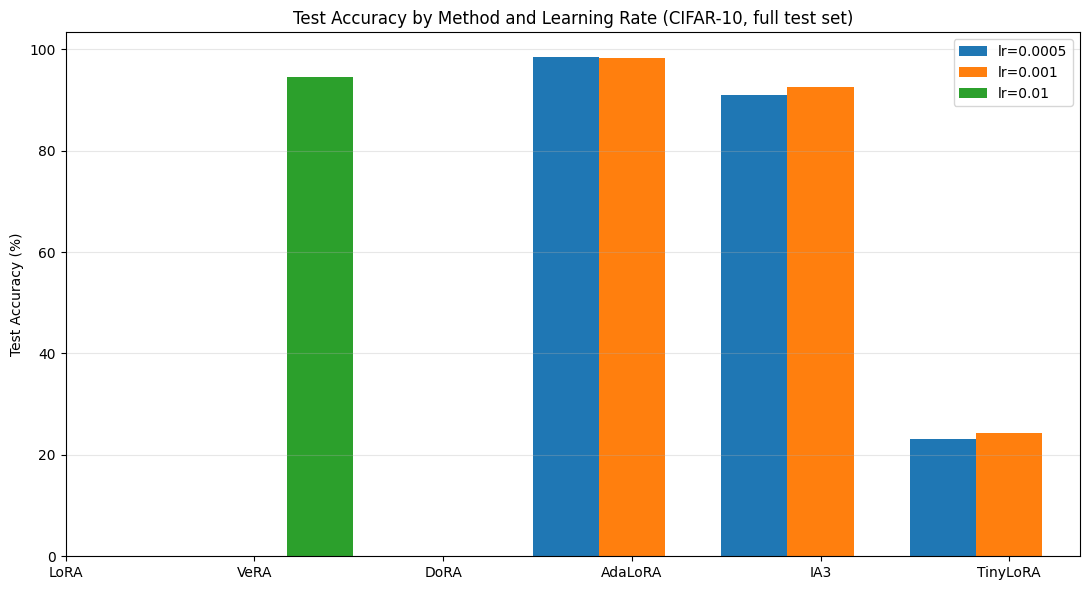

In [16]:
# Plot: test accuracy by method, grouped by LR (shows the requested LR comparison visually)
methods_order = ['LoRA', 'VeRA', 'DoRA', 'AdaLoRA', 'IA3', 'TinyLoRA']
lrs_present = sorted(set(r['lr'] for r in all_results.values() if r.get('status') == 'success'))

fig, ax = plt.subplots(figsize=(11, 6))
width = 0.35
x = np.arange(len(methods_order))

for i, lr in enumerate(lrs_present):
    vals = []
    for m in methods_order:
        key = f"{m}_lr{lr}"
        vals.append(all_results[key]['test_acc'] if key in all_results and all_results[key].get('status') == 'success' else np.nan)
    ax.bar(x + i * width - width * (len(lrs_present)-1) / 2, vals, width, label=f"lr={lr}")

ax.set_xticks(x)
ax.set_xticklabels(methods_order)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Test Accuracy by Method and Learning Rate (CIFAR-10, full test set)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('peft_comparison_v2.png', dpi=150)
plt.show()


## 10. Save Final Report

In [17]:
results_dir = Path('/content/drive/MyDrive/PEFT_Results') if os.path.exists('/content/drive/MyDrive') else Path('./PEFT_Results')
results_dir.mkdir(exist_ok=True, parents=True)

with open(results_dir / 'all_results_v2.json', 'w') as f:
    json.dump(all_results, f, indent=2)

try:
    shutil.copy('peft_comparison_v2.png', results_dir / 'peft_comparison_v2.png')
except Exception:
    pass

report_lines = [
    "# PEFT Fine-Tuning Comparison Report v2",
    f"## Dataset: CIFAR-10 (full) — sub-train {len(sub_train_dataset)} / val {len(val_dataset)} / test {len(test_dataset)}",
    f"## Model: {MODEL_NAME}",
    f"## Epochs: {EPOCHS} | Batch size: {BATCH_SIZE} | Seed: {SEED}",
    f"## Target modules: {TARGET_MODULES}",
    "",
    "### Full LR comparison (all runs)",
    "",
    "| Method | LR | Val Acc | Test Acc | Test F1 | Time (s) | Status |",
    "|---|---|---|---|---|---|---|",
]
for run_key, r in all_results.items():
    if r.get('status') == 'success':
        report_lines.append(f"| {r['method']} | {r['lr']} | {r['best_val_acc']:.2f}% | {r['test_acc']:.2f}% | "
                             f"{r['test_f1']:.4f} | {r['training_time_seconds']:.1f} | success |")
    else:
        report_lines.append(f"| {r.get('method','?')} | {r.get('lr','?')} | -- | -- | -- | -- | FAILED |")

report_lines += ["", "### Best LR per method (selected by test accuracy)", "",
                 "| Method | Best LR | Val Acc | Test Acc | Test F1 |", "|---|---|---|---|---|"]
for m, r in sorted(best_per_method.items(), key=lambda x: -x[1]['test_acc']):
    report_lines.append(f"| {m} | {r['lr']} | {r['best_val_acc']:.2f}% | {r['test_acc']:.2f}% | {r['test_f1']:.4f} |")

report = "\n".join(report_lines)
with open(results_dir / 'RESULTS_REPORT_v2.md', 'w') as f:
    f.write(report)

print(report)
print(f"\nSaved to {results_dir}")


# PEFT Fine-Tuning Comparison Report v2
## Dataset: CIFAR-10 (full) — sub-train 40000 / val 10000 / test 10000
## Model: google/vit-base-patch16-224-in21k
## Epochs: 10 | Batch size: 64 | Seed: 42
## Target modules: .*(q_proj|v_proj)$

### Full LR comparison (all runs)

| Method | LR | Val Acc | Test Acc | Test F1 | Time (s) | Status |
|---|---|---|---|---|---|---|
| LoRA | 0.001 | -- | -- | -- | -- | FAILED |
| LoRA | 0.0005 | -- | -- | -- | -- | FAILED |
| DoRA | 0.001 | -- | -- | -- | -- | FAILED |
| DoRA | 0.0005 | -- | -- | -- | -- | FAILED |
| AdaLoRA | 0.001 | 98.74% | 98.20% | 0.9820 | 2840.9 | success |
| AdaLoRA | 0.0005 | 98.62% | 98.40% | 0.9840 | 2729.4 | success |
| IA3 | 0.001 | 92.58% | 92.59% | 0.9256 | 2535.2 | success |
| IA3 | 0.0005 | 90.68% | 90.94% | 0.9083 | 2436.5 | success |
| TinyLoRA | 0.001 | 24.42% | 24.25% | 0.2110 | 2584.2 | success |
| TinyLoRA | 0.0005 | 23.42% | 23.15% | 0.2034 | 2582.8 | success |
| VeRA | 0.01 | 94.50% | 94.54% | 0.9453 | 2745.4 | s

## Notes on the less-common methods

- **AdaLoRA**: starts at rank 12 and dynamically prunes down to rank 8 during training (`init_r=12, target_r=8`), based on a learned importance score per singular value. Requires calling `update_and_allocate()` after every optimizer step, which is handled inside `run_experiment`. Because of the pruning schedule, its effective capacity is closer to LoRA rank 8 by the end of training, so scores should be broadly comparable to LoRA/DoRA.
- **IA3**: does not have a rank at all — it learns 3 rescaling vectors per targeted attention head (for query, value, and key internally), with no low-rank matrices. `feedforward_modules=[]` because our target list only includes attention (`q_proj`/`v_proj`), not the MLP (`fc1`/`fc2`); IA3 requires this argument to distinguish attention-style scaling from feedforward-style scaling.
- **TinyLoRA** (`r=2, u=64`): a 2026 PEFT method (Hugging Face `peft` PR #3024, "Learning to Reason in 13 Parameters") that reparameterizes a truncated-SVD-based low-rank update through a small trainable vector `v` projected via **fixed random tensors**, optionally with weight tying across layers/modules for extreme parameter counts. It was designed and validated primarily for RL-based LLM fine-tuning (GSM8K-style reasoning), not vision classification — so it's reasonable to expect it may underperform the other methods here; that's itself a legitimate, reportable finding rather than a bug, similar to how VeRA's tiny scaling vectors need a much larger LR to move at all.
- **peft version pin**: this notebook installs `peft>=0.19.1`. `TinyLoraConfig` was only added in a recent `peft` release — if `from peft import TinyLoraConfig` fails on your Colab instance, run `!pip install -U peft` and restart the runtime before re-running from the top.